# Predicción de géneros musicales con métricas de Spotify

## Objetivo del trabajo

El objetivo es resolver un problema de clasificación multiclase: predecir el género musical de una canción a partir de sus características acústicas y métricas disponibles en el dataset de Spotify.

La variable objetivo es `Expected`, que contiene seis géneros: `acoustic`, `classical`, `electronic`, `hip-hop`, `jazz` y `rock`. La columna `Id` identifica cada registro y no debería utilizarse como predictor, porque funciona como identificador y podría introducir patrones espurios.

Además de buscar un buen resultado en la competencia de Kaggle, el análisis debe permitir entender qué características diferencian a los géneros, qué transformaciones necesitan los datos y qué modelo ofrece el mejor equilibrio entre desempeño e interpretabilidad.

## Restricciones

- Trabajar únicamente con `train.csv` y `test.csv` provistos para el trabajo.
- No utilizar APIs externas ni cruzar los datos con el dataset original para recuperar etiquetas.
- Separar correctamente las variables predictoras (`X`) de la variable objetivo (`y`).
- Evitar fuga de información: todo ajuste de transformaciones debe hacerse utilizando únicamente los datos de entrenamiento.


## 1. Carga y revisión inicial de los datos

Cargar `train.csv` y `test.csv` desde la carpeta de datos. Revisar las dimensiones de ambos conjuntos, los tipos de datos, los nombres de las columnas y algunos registros de ejemplo.

También verificar valores faltantes, filas duplicadas y cardinalidad de la variable objetivo. Comparar las columnas de entrenamiento y prueba para confirmar que `Expected` está presente únicamente en entrenamiento y que `Id` es un identificador.

**Pregunta que buscamos responder:** ¿Con qué datos contamos, qué problemas de calidad existen y qué columnas pueden utilizarse legítimamente para predecir el género?

**Conclusión esperada:** dejar documentado el tamaño de los conjuntos, la distribución de las clases, la presencia o ausencia de faltantes y la decisión de excluir `Id` de las variables predictoras.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
print(train.dtypes)

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object


In [4]:
for feature in train.columns:
    print(f"{feature}: {train[feature].isnull().sum()} valores NaN")

popularity: 0 valores NaN
duration_ms: 0 valores NaN
explicit: 0 valores NaN
danceability: 0 valores NaN
energy: 0 valores NaN
key: 0 valores NaN
loudness: 0 valores NaN
mode: 0 valores NaN
speechiness: 0 valores NaN
acousticness: 0 valores NaN
instrumentalness: 0 valores NaN
liveness: 0 valores NaN
valence: 0 valores NaN
tempo: 0 valores NaN
time_signature: 0 valores NaN
Expected: 0 valores NaN
Id: 0 valores NaN


In [5]:
print(test.dtypes)

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Id                    int64
dtype: object


In [6]:
for feature in test.columns:
    print(f"{feature}: {test[feature].isnull().sum()} valores NaN")

popularity: 0 valores NaN
duration_ms: 0 valores NaN
explicit: 0 valores NaN
danceability: 0 valores NaN
energy: 0 valores NaN
key: 0 valores NaN
loudness: 0 valores NaN
mode: 0 valores NaN
speechiness: 0 valores NaN
acousticness: 0 valores NaN
instrumentalness: 0 valores NaN
liveness: 0 valores NaN
valence: 0 valores NaN
tempo: 0 valores NaN
time_signature: 0 valores NaN
Id: 0 valores NaN


> Analizando los datasets de train y test vemos que no hay valores NaN. En los dataset vamos a eliminar la columna de ID para no sesgar el modelo, ya que no tiene peso en la prediccion. 

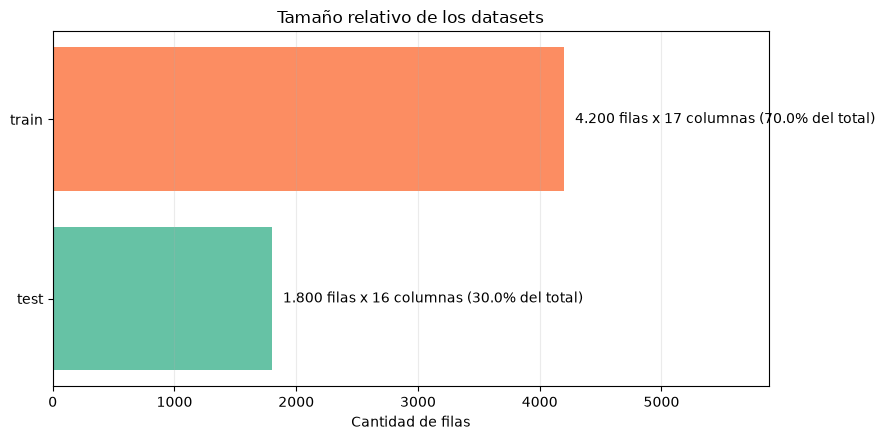

In [7]:
sizes = pd.DataFrame({
    "Dataset": ["train", "test"],
    "Filas": [len(train), len(test)],
    "Columnas": [train.shape[1], test.shape[1]],
}).sort_values("Filas", ascending=True)

sizes["Etiqueta"] = sizes.apply(
    lambda row: f"{int(row['Filas']):,} filas x {int(row['Columnas'])} columnas".replace(",", "."),
    axis=1,
)
total_filas = sizes["Filas"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(sizes["Dataset"], sizes["Filas"], color=["#66c2a5", "#fc8d62"])

for bar, (_, row) in zip(bars, sizes.iterrows()):
    ax.text(
        bar.get_width() + total_filas * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Etiqueta']} ({row['Filas'] / total_filas:.1%} del total)",
        va="center",
    )

ax.set_title("Tamaño relativo de los datasets")
ax.set_xlabel("Cantidad de filas")
ax.set_ylabel("")
ax.set_xlim(0, sizes["Filas"].max() * 1.4)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


> Los datos estan separados en un 70% de train y un 30% de test. Seguimos con mas analisis de datos.

## 2. Análisis Exploratorio de Datos (EDA)

Analizar cómo se distribuyen las variables numéricas y cómo se relacionan con `Expected`. Incluir al menos tres visualizaciones relevantes, por ejemplo:

1. Distribución de géneros mediante un gráfico de barras para detectar desbalance de clases.
2. Boxplots o violin plots de variables como `danceability`, `energy`, `acousticness`, `instrumentalness`, `valence` y `tempo`, separados por género.
3. Matriz de correlación entre las variables numéricas para detectar redundancia y relaciones fuertes.

También se pueden incluir histogramas, gráficos de densidad o proyecciones bidimensionales para complementar el análisis.

**Pregunta que buscamos responder:** ¿Qué características parecen diferenciar mejor a los géneros y cuáles presentan distribuciones similares entre clases?

**Conclusión esperada:** identificar variables potencialmente útiles, observar si existen clases difíciles de separar visualmente y señalar posibles problemas de escala, outliers o desbalance que deban tratarse antes de modelar.

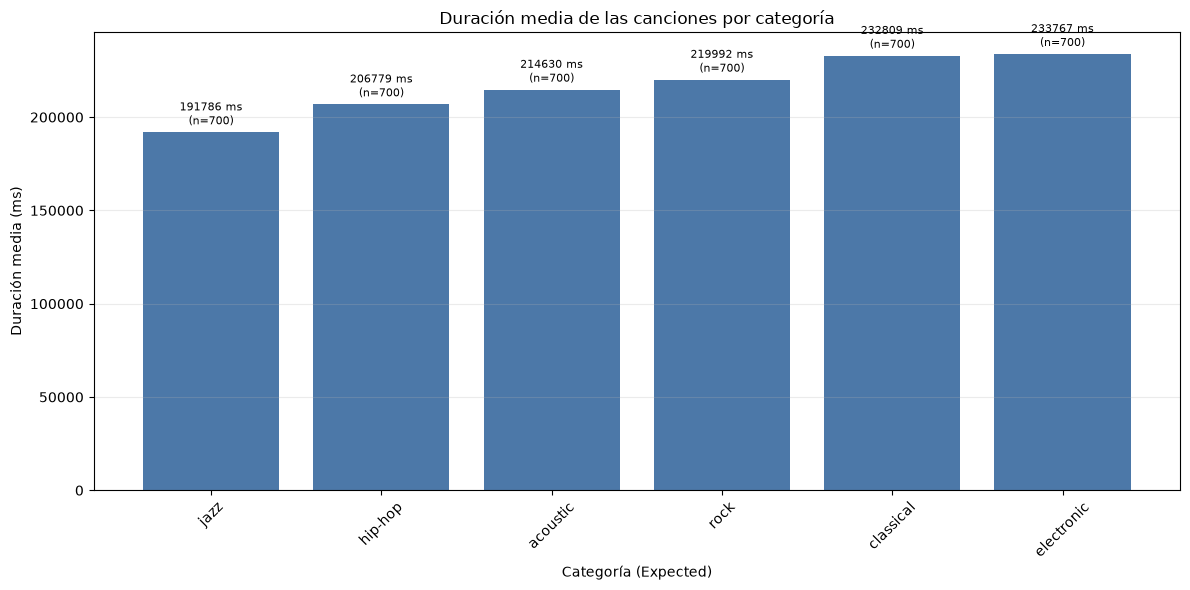

In [8]:
# Duración media de las canciones por categoría
resumen_duracion = (
    train.groupby("Expected")
    .agg(duracion_media_ms=("duration_ms", "mean"), cantidad_canciones=("duration_ms", "size"))
    .sort_values("duracion_media_ms")
)

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(
    resumen_duracion.index,
    resumen_duracion["duracion_media_ms"],
    color="#4c78a8",
)

for barra, (_, fila) in zip(barras, resumen_duracion.iterrows()):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + resumen_duracion["duracion_media_ms"].max() * 0.01,
        f"{fila['duracion_media_ms']:.0f} ms\n(n={int(fila['cantidad_canciones'])})",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_title("Duración media de las canciones por categoría")
ax.set_xlabel("Categoría (Expected)")
ax.set_ylabel("Duración media (ms)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


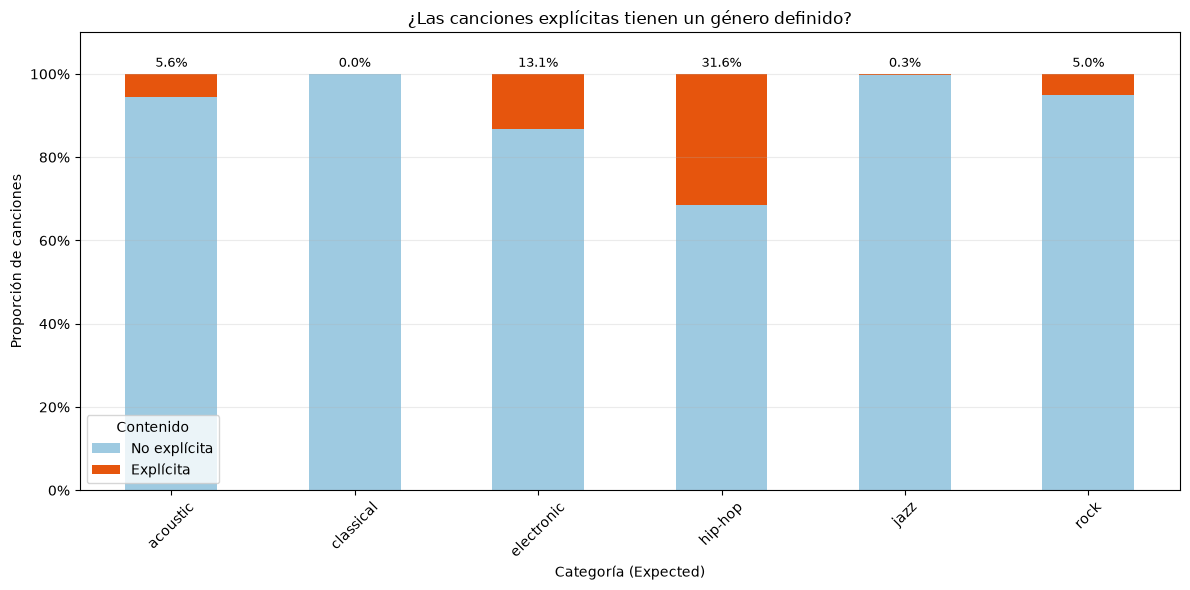

In [9]:
# Proporción de canciones explícitas y no explícitas por categoría
proporcion_explicit = pd.crosstab(
    train["Expected"],
    train["explicit"],
    normalize="index",
).reindex(columns=[False, True], fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
proporcion_explicit.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#9ecae1", "#e6550d"],
)

for posicion, (_, fila) in enumerate(proporcion_explicit.iterrows()):
    porcentaje_explicito = fila[True]
    ax.text(
        posicion,
        1.01,
        f"{porcentaje_explicito:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("¿Las canciones explícitas tienen un género definido?")
ax.set_xlabel("Categoría (Expected)")
ax.set_ylabel("Proporción de canciones")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda valor, posicion: f"{valor:.0%}"))
ax.legend(["No explícita", "Explícita"], title="Contenido")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


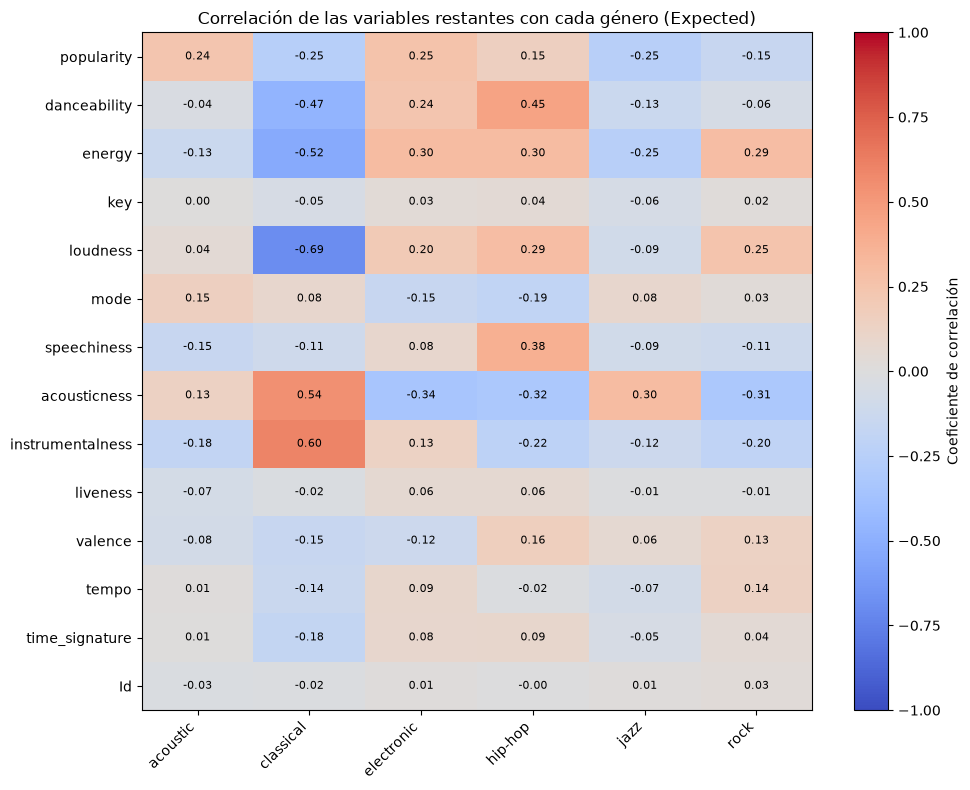

In [10]:
# Correlación de las variables restantes con cada género de Expected
variables = train.drop(columns=["Expected", "explicit", "duration_ms"]).select_dtypes(
    include=["number", "bool"]
).copy()
generos = pd.get_dummies(train["Expected"], dtype=int)

correlaciones_genero = pd.DataFrame({
    genero: variables.corrwith(generos[genero])
    for genero in generos.columns
})

fig, ax = plt.subplots(figsize=(10, 8))
imagen = ax.imshow(correlaciones_genero, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(correlaciones_genero.columns)))
ax.set_yticks(range(len(correlaciones_genero.index)))
ax.set_xticklabels(correlaciones_genero.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones_genero.index)
ax.set_title("Correlación de las variables restantes con cada género (Expected)")

for fila in range(len(correlaciones_genero.index)):
    for columna in range(len(correlaciones_genero.columns)):
        ax.text(
            columna,
            fila,
            f"{correlaciones_genero.iloc[fila, columna]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(imagen, ax=ax, label="Coeficiente de correlación")
plt.tight_layout()
plt.show()


> _Conclusiones:_

> En el primer grafico comparamos los generos con la duracion de las canciones promedio y vemos que en lineas generales no varia tanto, la unica que esta un poco por debajo es jazz, mientras que las que más duration tienen son electronica y clasica.

> En el segundo grafico, podemos encontrar la primer gran diferencia entre los generos, comparamos el porcentaje de las canciones que tenian palabras explicitas y concluimos que hiphop es la que más canciones tiene con palabras inapropiadas (gran diferencia). Seguido, por electronica. Despues, los generos jazz y clasica no tienen palabras explicitas en casi ninguna canción.

> En el ultimo grafico vemos que las variables key y liveness no tienen mucha correlación con ningun genero a predecir por lo que las vamos a borrar del dataset. Por decisión de modelado. Las borramos de train y de test para no generar fallas silenciosas.

> _Aclaración: Las visualizaciones estan basadas puramente en el csv de train (NO DATA LEAKAGE)._

In [11]:
train = train.drop( columns = ["liveness"])
train = train.drop( columns = ["key"])
test = test.drop( columns = ["liveness"])
test = test.drop( columns = ["key"])

## 3. Preprocesamiento y preparación del conjunto de modelado

Separar la variable objetivo `Expected` y excluir `Id` de las variables predictoras. Definir una estrategia reproducible para dividir el conjunto de entrenamiento en entrenamiento y validación estratificada.

Evaluar qué preprocesamiento corresponde aplicar: tratamiento de valores faltantes si aparecieran, escalado de variables numéricas, codificación de variables booleanas o categóricas y tratamiento de valores atípicos si el análisis exploratorio lo justifica. Usar un `Pipeline` o una estructura equivalente para que las transformaciones se ajusten solamente sobre el subconjunto de entrenamiento.

**Pregunta que buscamos responder:** ¿Qué transformaciones necesitan los datos para que los modelos aprendan correctamente sin introducir fuga de información?

**Conclusión esperada:** justificar cada transformación, indicar qué variables entran finalmente al modelo y dejar preparada una validación comparable para todos los algoritmos.

In [ ]:
# Separar Expected y excluir Id de las predictorias. Para despues entregar en Kaggle.

# acá SÍ tenemos la respuesta correcta
y_train = train["Expected"]
X_train = train.drop(columns=["Expected", "Id"])

# acá NO tenemos la respuesta, hay que predecirla
# Guardamos el Id aparte porque lo vamos a necesitar para el archivo de entrega
test_ids = test["Id"]
X_test = test.drop(columns=["Id"])

> Del análisis del punto 1, no tenemos valores faltantes en ningun dataset.

> Como vamos a utlilizar modelos con arboles de decisiones no vamos a escalar datos numericos.

> Tampoco vamos a modificar variables booleanas por la misma razón.

> Vamos a convertir la variable categórica Expected a numérica usando Label Encoder para poder trabajar con algoritmos de árboles de decisión. Esto no genera sesgo de distancia, porque Expected es la variable a predecir (target) y no una feature. El algoritmo de clasificación no realiza operaciones como restas, distancias entre los valores del target, sino que los trata como etiquetas de clase independientes. 

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train["Expected"])


## 4. Implementación de modelos

Implementar al menos dos modelos de Machine Learning distintos para clasificación multiclase. Conviene elegir modelos con supuestos y comportamientos diferentes, por ejemplo un modelo lineal como `LogisticRegression` y un modelo basado en árboles como `RandomForestClassifier` o `HistGradientBoostingClassifier`.

Entrenar ambos modelos con el mismo esquema de división o validación cruzada estratificada. Mantener fijos los datos de evaluación y las métricas para que la comparación sea justa.

**Pregunta que buscamos responder:** ¿Un modelo lineal alcanza para separar los géneros o un modelo no lineal captura mejor las relaciones entre las métricas acústicas?

**Conclusión esperada:** reportar los modelos utilizados, sus principales hiperparámetros y una primera comparación de resultados, sin seleccionar un modelo únicamente por intuición.

## 5. Evaluación y comparación de resultados

Evaluar los modelos sobre el conjunto de validación utilizando accuracy y macro-F1. La accuracy indica el porcentaje total de predicciones correctas, mientras que macro-F1 asigna el mismo peso a cada género y permite detectar si el modelo funciona mal en alguna clase minoritaria.

Complementar las métricas con una matriz de confusión y un classification report por género. Si se utiliza validación cruzada, informar la media y la dispersión de las métricas, no solamente el mejor resultado.

**Pregunta que buscamos responder:** ¿Qué modelo generaliza mejor y qué géneros se confunden entre sí?

**Conclusión esperada:** seleccionar el modelo final con evidencia, explicando el balance entre desempeño global, desempeño por clase, estabilidad y complejidad.

## 6. Entrenamiento final y archivo de submission

Una vez seleccionado el modelo, reentrenarlo utilizando todos los registros etiquetados de `train.csv`. Luego predecir la columna `Expected` para cada fila de `test.csv` y construir el archivo de submission con las columnas y el formato exigidos por la competencia, conservando los valores de `Id` sin modificarlos.

Verificar antes de exportar que el archivo tenga exactamente una predicción por fila de test, que no haya valores nulos y que las clases predichas pertenezcan al conjunto esperado. Guardar el resultado como CSV y, si corresponde, registrar el score obtenido en Kaggle.

**Pregunta que buscamos responder:** ¿Cómo se traduce el modelo validado en una entrega reproducible para datos no etiquetados?

**Conclusión esperada:** dejar documentado el modelo final, la métrica local y el score de Kaggle, aclarando cualquier diferencia entre ambos resultados.

## 7. Conclusiones del análisis

Resumir los hallazgos principales del EDA, las decisiones de preprocesamiento y la comparación de modelos. Indicar qué variables fueron más informativas según la evidencia disponible y qué géneros resultaron más fáciles o difíciles de clasificar.

Comparar el desempeño local con el resultado de Kaggle y discutir posibles causas de diferencias, como la composición del conjunto de test, la variabilidad del muestreo o el sobreajuste al conjunto de validación.

**Pregunta que buscamos responder:** ¿Qué aprendimos sobre la relación entre las características acústicas y el género musical, más allá del score de la competencia?

**Conclusión esperada:** presentar una respuesta crítica y respaldada por métricas, visualizaciones y observaciones del comportamiento del modelo.

## Bonus point. Interpretabilidad y análisis de errores

Analizar por qué el modelo se equivoca y qué variables influyen en sus decisiones. Utilizar herramientas acordes al modelo, como importancia de variables, coeficientes, permutation importance o SHAP si está disponible en el entorno. Relacionar estos resultados con la matriz de confusión y estudiar algunos ejemplos representativos de cada confusión frecuente.

También se puede comparar el comportamiento del modelo entre géneros y evaluar si la confianza de las predicciones cambia según la clase. No se busca solamente mejorar el score, sino entender cuándo el modelo es confiable y qué información adicional podría ayudarlo.

**Pregunta de investigación adicional:** ¿Las variables más importantes para el modelo coinciden con las diferencias observadas en el EDA y con una interpretación musical razonable?

**Valor agregado:** este análisis conecta el rendimiento estadístico con una explicación del fenómeno musical. Puede revelar sesgos del dataset, variables redundantes o géneros que necesitan más datos, y permite justificar mejor la elección del modelo final.